In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Import existing project utilities
import data_utils as du

# Global Configuration
DATA_ROOT = '../data'  # Adjust if necessary
FS_AUDIO = 4800
FS_MOTION = 100

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Load Metadata
metadata_path = os.path.join(DATA_ROOT, 'metadata.csv')
df_meta = du.load_metadata(metadata_path)

print(f"V2 Setup Complete. Loaded {len(df_meta)} records.")

V2 Setup Complete. Loaded 71 records.


In [2]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = signal.butter(order, cutoff/nyq, btype='low', analog=False)
    return b, a

def load_record_preprocessed(record_id, metadata_df, data_root=DATA_ROOT):
    """Loads and preprocesses a full record (Filtering & Resampling)."""
    row = du.get_record_row(metadata_df, record_id)
    csv_path = du.resolve_record_path(row, data_root)
    raw_data = du.load_record_array(csv_path)
    
    pulm = raw_data[:, 0]
    amb = raw_data[:, 1]
    ch3 = raw_data[:, 2].astype(int)
    accz = raw_data[:, 3]
    
    stretch_raw, cough_label = du.decode_channel3(ch3)
    
    # Audio
    pulm_centered, amb_centered = pulm - np.median(pulm), amb - np.median(amb)
    b_bp, a_bp = butter_bandpass(60, 2200, FS_AUDIO, order=4)
    pulm_bp = signal.filtfilt(b_bp, a_bp, pulm_centered)
    amb_bp = signal.filtfilt(b_bp, a_bp, amb_centered)
    
    # Motion
    stretch_centered = stretch_raw - np.median(stretch_raw)
    num_samples_motion = int(len(stretch_centered) * (FS_MOTION / FS_AUDIO))
    
    stretch_resampled = signal.resample(stretch_centered, num_samples_motion)
    accz_resampled = signal.resample(accz, num_samples_motion)
    
    b_lp, a_lp = butter_lowpass(20, FS_MOTION, order=4)
    stretch_lp = signal.filtfilt(b_lp, a_lp, stretch_resampled)
    accz_lp = signal.filtfilt(b_lp, a_lp, accz_resampled)
    
    return {
        'record_id': record_id,
        'pulm_bp': pulm_bp, 'amb_bp': amb_bp,
        'stretch_lp': stretch_lp, 'accz_lp': accz_lp,
        'cough_label': cough_label,
        'duration_sec': len(pulm_bp) / FS_AUDIO
    }

print("load_record_preprocessed defined.")

load_record_preprocessed defined.


In [3]:
def build_centered_windows_for_record(preprocessed_record, window_length_sec=1.0, hop_length_sec=0.25):
    """
    V2 Upgrade: 
    1. hop_length is reduced to 0.25s for higher temporal resolution.
    2. Center-Focused Labeling: A window is ONLY labeled as '1' if a cough 
       is present in the strictly central 20% of the window. This prevents
       the visual illusion of predictions starting too early.
    """
    record_id = preprocessed_record['record_id']
    pulm = preprocessed_record['pulm_bp']
    amb = preprocessed_record['amb_bp']
    stretch = preprocessed_record['stretch_lp']
    accz = preprocessed_record['accz_lp']
    labels_raw = preprocessed_record['cough_label']
    
    audio_win_samples = int(window_length_sec * FS_AUDIO)
    audio_hop_samples = int(hop_length_sec * FS_AUDIO)
    motion_win_samples = int(window_length_sec * FS_MOTION)
    
    # Define the "Center Region" (middle 20% of the window)
    center_start_idx = int(audio_win_samples * 0.40)
    center_end_idx = int(audio_win_samples * 0.60)
    
    audio_windows, motion_windows, labels, spans = [], [], [], []
    num_samples_audio = len(pulm)
    
    for start_idx_audio in range(0, num_samples_audio - audio_win_samples + 1, audio_hop_samples):
        end_idx_audio = start_idx_audio + audio_win_samples
        start_sec, end_sec = start_idx_audio / FS_AUDIO, end_idx_audio / FS_AUDIO
        
        start_idx_motion = int(start_sec * FS_MOTION)
        end_idx_motion = start_idx_motion + motion_win_samples
        
        if end_idx_motion > len(stretch): break
            
        # Extract Tensors
        w_audio = np.stack([pulm[start_idx_audio:end_idx_audio], amb[start_idx_audio:end_idx_audio]], axis=0)
        w_motion = np.stack([stretch[start_idx_motion:end_idx_motion], accz[start_idx_motion:end_idx_motion]], axis=0)
        
        # --- V2 STRICT LABELING RULE ---
        # Extract only the center 20% of the labels for this window
        w_labels_center = labels_raw[start_idx_audio + center_start_idx : start_idx_audio + center_end_idx]
        w_label = 1 if np.any(w_labels_center > 0) else 0
        
        audio_windows.append(w_audio)
        motion_windows.append(w_motion)
        labels.append(w_label)
        spans.append((start_sec, end_sec))
        
    return {
        'record_id': record_id,
        'audio_windows': np.array(audio_windows, dtype=np.float32),
        'motion_windows': np.array(motion_windows, dtype=np.float32),
        'labels': np.array(labels, dtype=np.int64),
        'spans': spans
    }

print("build_centered_windows_for_record defined.")

build_centered_windows_for_record defined.


Visualizing V2 Windowing for Record: 0


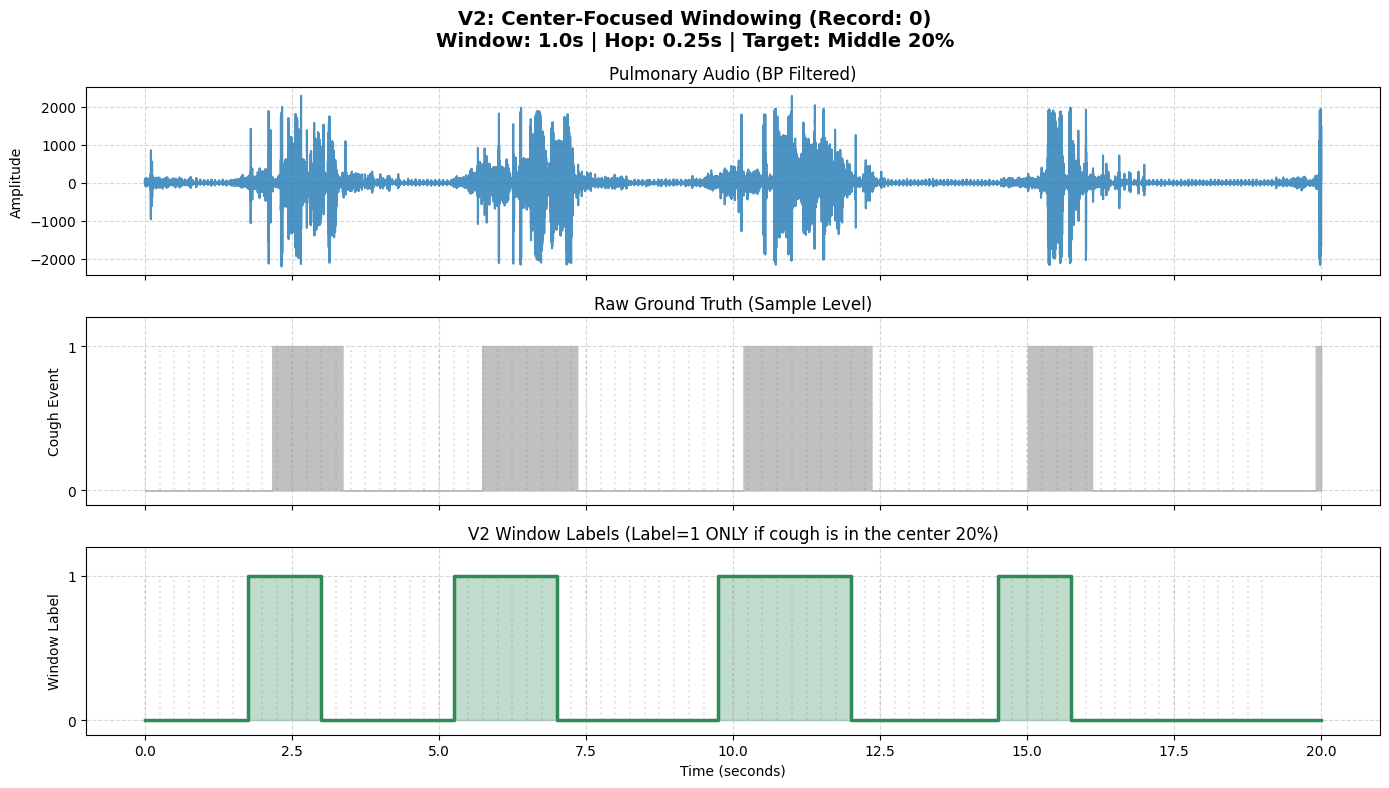

In [4]:
# 1. Select the same test record we used in V1 for a fair comparison
test_record_id = df_meta.iloc[0]['record_id']
print(f"Visualizing V2 Windowing for Record: {test_record_id}")

# 2. Process the record using the new V2 logic
prep_data = load_record_preprocessed(test_record_id, df_meta, DATA_ROOT)
v2_win_results = build_centered_windows_for_record(
    prep_data, 
    window_length_sec=1, 
    hop_length_sec=0.25  # Note the higher resolution hop
)

# 3. Prepare Time Axes
duration = prep_data['duration_sec']
pulm = prep_data['pulm_bp']
labels_raw = prep_data['cough_label']
t_audio = np.linspace(0, duration, len(pulm), endpoint=False)

# Prepare step function data for the V2 labels
spans = v2_win_results['spans']
labels_v2 = v2_win_results['labels']

t_window_steps = [s[0] for s in spans] + [spans[-1][1]]
step_v2 = list(labels_v2) + [labels_v2[-1]]

# 4. Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"V2: Center-Focused Windowing (Record: {test_record_id})\nWindow: 1.0s | Hop: 0.25s | Target: Middle 20%", fontsize=14, fontweight='bold')

# Plot A: Pulmonary Audio for context
axes[0].plot(t_audio, pulm, color='#1f77b4', alpha=0.8)
axes[0].set_title('Pulmonary Audio (BP Filtered)')
axes[0].set_ylabel('Amplitude')

# Plot B: Raw Ground Truth
axes[1].fill_between(t_audio, 0, labels_raw, color='silver', step='pre')
axes[1].set_title('Raw Ground Truth (Sample Level)')
axes[1].set_ylabel('Cough Event')

# Plot C: New V2 Window Labels
axes[2].step(t_window_steps, step_v2, where='post', color='seagreen', linewidth=2.5)
axes[2].fill_between(t_window_steps, 0, step_v2, step='post', color='seagreen', alpha=0.3)
axes[2].set_title("V2 Window Labels (Label=1 ONLY if cough is in the center 20%)")
axes[2].set_ylabel('Window Label')
axes[2].set_xlabel('Time (seconds)')

# Formatting
for ax in axes[1:]:
    ax.set_yticks([0, 1])
    ax.set_ylim(-0.1, 1.2)
    
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    # Add vertical lines to show the new 0.25s grid resolution
    ax.vlines([s[0] for s in spans], 0, 1, colors='gray', linestyles=':', alpha=0.2)

plt.tight_layout()
plt.show()

In [5]:
import torch

def augment_multimodal_batch(audio_batch, motion_batch, shift_max_sec=0.15, noise_level_audio=0.02, noise_level_motion=0.01):
    """
    Applies synchronized Data Augmentation to Audio and Motion tensors.
    1. Additive White Gaussian Noise (AWGN)
    2. Synchronized Time-Shifting (Rolling)
    """
    B, C_a, T_a = audio_batch.shape
    _, C_m, T_m = motion_batch.shape
    
    # Clone to avoid modifying the original dataset tensors in-place
    aug_audio = audio_batch.clone()
    aug_motion = motion_batch.clone()
    
    # 1. ADDITIVE WHITE GAUSSIAN NOISE (AWGN)
    audio_noise = torch.randn_like(aug_audio) * noise_level_audio
    motion_noise = torch.randn_like(aug_motion) * noise_level_motion
    
    aug_audio += audio_noise
    aug_motion += motion_noise
    
    # 2. SYNCHRONIZED TIME SHIFTING (Roll)
    for i in range(B):
        # Generate a random shift between -shift_max_sec and +shift_max_sec
        shift_sec = (torch.rand(1).item() * 2 - 1) * shift_max_sec
        
        # Convert seconds to exact integer samples based on respective sampling rates
        shift_samples_audio = int(shift_sec * FS_AUDIO)
        shift_samples_motion = int(shift_sec * FS_MOTION)
        
        # Apply circular shift (roll)
        aug_audio[i] = torch.roll(aug_audio[i], shifts=shift_samples_audio, dims=-1)
        aug_motion[i] = torch.roll(aug_motion[i], shifts=shift_samples_motion, dims=-1)
        
        # Mask the rolled-over edges with zeros to prevent unnatural jumps at the boundaries
        if shift_samples_audio > 0:
            aug_audio[i, :, :shift_samples_audio] = 0
            aug_motion[i, :, :shift_samples_motion] = 0
        elif shift_samples_audio < 0:
            aug_audio[i, :, shift_samples_audio:] = 0
            aug_motion[i, :, shift_samples_motion:] = 0
            
    return aug_audio, aug_motion

print("V2 Data Augmentation function defined.")

V2 Data Augmentation function defined.


In [6]:
from sklearn.model_selection import train_test_split

def split_records(metadata_df, test_size=0.15, val_size=0.15, random_state=42):
    unique_records = metadata_df['record_id'].unique()
    train_val_records, test_records = train_test_split(
        unique_records, test_size=test_size, random_state=random_state
    )
    val_ratio = val_size / (1.0 - test_size)
    train_records, val_records = train_test_split(
        train_val_records, test_size=val_ratio, random_state=random_state
    )
    return train_records, val_records, test_records

def build_v2_dataset(record_ids, metadata_df, window_length_sec=1.0, hop_length_sec=0.25):
    """Aggregates V2 centered windows for a list of records."""
    all_audio, all_motion, all_labels = [], [], []
    
    for rec_id in record_ids:
        prep_record = load_record_preprocessed(rec_id, metadata_df, DATA_ROOT)
        win_results = build_centered_windows_for_record(
            prep_record, window_length_sec, hop_length_sec
        )
        
        if len(win_results['labels']) > 0:
            all_audio.append(win_results['audio_windows'])
            all_motion.append(win_results['motion_windows'])
            all_labels.append(win_results['labels'])
            
    return np.vstack(all_audio), np.vstack(all_motion), np.concatenate(all_labels)

# 1. Execute Split (Using the exact same seed as V1 for a fair comparison)
print("--- Executing V2 Record-Level Split ---")
train_recs, val_recs, test_recs = split_records(df_meta)
print(f"Record Split -> Train: {len(train_recs)}, Val: {len(val_recs)}, Test: {len(test_recs)}\n")

# 2. Build Datasets
print("--- Building V2 Training Set ---")
X_a_train, X_m_train, y_train = build_v2_dataset(train_recs, df_meta)
print(f"Train Audio: {X_a_train.shape} | Labels: {y_train.shape} | Positive: {np.sum(y_train)} ({np.mean(y_train)*100:.1f}%)")

print("\n--- Building V2 Validation Set ---")
X_a_val, X_m_val, y_val = build_v2_dataset(val_recs, df_meta)
print(f"Val Audio: {X_a_val.shape} | Labels: {y_val.shape} | Positive: {np.sum(y_val)} ({np.mean(y_val)*100:.1f}%)")

print("\n--- Building V2 Test Set ---")
X_a_test, X_m_test, y_test = build_v2_dataset(test_recs, df_meta)
print(f"Test Audio: {X_a_test.shape} | Labels: {y_test.shape} | Positive: {np.sum(y_test)} ({np.mean(y_test)*100:.1f}%)")

--- Executing V2 Record-Level Split ---
Record Split -> Train: 49, Val: 11, Test: 11

--- Building V2 Training Set ---


Train Audio: (3773, 2, 4800) | Labels: (3773,) | Positive: 600 (15.9%)

--- Building V2 Validation Set ---


Val Audio: (847, 2, 4800) | Labels: (847,) | Positive: 163 (19.2%)

--- Building V2 Test Set ---


Test Audio: (847, 2, 4800) | Labels: (847,) | Positive: 155 (18.3%)


In [7]:
class CoughMultimodalDataset(Dataset):
    def __init__(self, X_audio, X_motion, labels):
        self.audio = torch.tensor(X_audio, dtype=torch.float32)
        self.motion = torch.tensor(X_motion, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32) # Float32 for BCEWithLogitsLoss
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {'audio': self.audio[idx], 'motion': self.motion[idx], 'label': self.labels[idx]}

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(CoughMultimodalDataset(X_a_train, X_m_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CoughMultimodalDataset(X_a_val, X_m_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CoughMultimodalDataset(X_a_test, X_m_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# Redefine the V1 Architecture
class DualBranchCoughCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_branch = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=15, stride=2, padding=7), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) 
        )
        self.motion_branch = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=5, stride=1, padding=2), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1)
        )

    def forward(self, audio, motion):
        x_a = self.audio_branch(audio).squeeze(-1)
        x_m = self.motion_branch(motion).squeeze(-1)
        return self.classifier(torch.cat((x_a, x_m), dim=1)).squeeze(-1)

model_v2 = DualBranchCoughCNN()
print("\nV2 DataLoaders and Model Architecture initialized successfully.")


V2 DataLoaders and Model Architecture initialized successfully.


In [8]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. Calculate new dynamic pos_weight for V2
# Because our Center-Focused rule is much stricter, positive (cough) windows are rarer now.
# This mathematically balances the loss function so the model doesn't ignore coughs.
num_pos_v2 = np.sum(y_train)
num_neg_v2 = len(y_train) - num_pos_v2
pos_weight_val_v2 = num_neg_v2 / num_pos_v2
pos_weight_v2 = torch.tensor([pos_weight_val_v2], dtype=torch.float32)

print(f"Calculated pos_weight for V2 BCE Loss: {pos_weight_val_v2:.2f}")

criterion_v2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_v2)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=1e-3, weight_decay=1e-4)

# 2. Add the Learning Rate Scheduler
# factor=0.5 cuts LR in half. patience=3 means it waits 3 epochs of no improvement before acting.
scheduler_v2 = ReduceLROnPlateau(optimizer_v2, mode='min', factor=0.5, patience=3)

def train_v2_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20):
    train_losses, val_losses, val_accuracies, lr_hist = [], [], [], []

    print(f"\nStarting V2 Phase 1 Training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # -- TRAINING PHASE --
        model.train()
        running_train_loss = 0.0

        for batch in train_loader:
            audio = batch['audio']
            motion = batch['motion']
            labels = batch['label']

            # ---> V2 UPGRADE: Apply Augmentation dynamically on the batch <---
            # Max shift is 0.15s. Noise levels are kept subtle.
            audio_aug, motion_aug = augment_multimodal_batch(
                audio, motion, shift_max_sec=0.0, noise_level_audio=0.02, noise_level_motion=0.01
            )

            optimizer.zero_grad()
            logits = model(audio_aug, motion_aug)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * audio.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # -- VALIDATION PHASE --
        model.eval()
        running_val_loss = 0.0
        correct_preds, total_preds = 0, 0

        with torch.no_grad():
            for batch in val_loader:
                audio = batch['audio']
                motion = batch['motion']
                labels = batch['label']

                # CRITICAL: NO augmentation during validation!
                logits = model(audio, motion)
                loss = criterion(logits, labels)
                running_val_loss += loss.item() * audio.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                correct_preds += (preds == labels).sum().item()
                total_preds += labels.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_preds / total_preds

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # ---> V2 UPGRADE: Step the scheduler based on validation loss <---
        scheduler.step(epoch_val_loss)

        # Get current learning rate for logging
        current_lr = optimizer.param_groups[0]['lr']
        lr_hist.append(current_lr)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | LR: {current_lr:.5f} | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

    return train_losses, val_losses, val_accuracies, lr_hist

print("V2 Training loop defined with Augmentation and LR Scheduler.")

Calculated pos_weight for V2 BCE Loss: 5.29


V2 Training loop defined with Augmentation and LR Scheduler.



Starting V2 Phase 1 Training for 25 epochs...


Epoch 01/25 | LR: 0.00100 | Train Loss: 0.6335 | Val Loss: 0.6175 | Val Acc: 84.06%


Epoch 02/25 | LR: 0.00100 | Train Loss: 0.3255 | Val Loss: 0.6899 | Val Acc: 92.92%


Epoch 03/25 | LR: 0.00100 | Train Loss: 0.2730 | Val Loss: 0.6697 | Val Acc: 93.62%


Epoch 04/25 | LR: 0.00100 | Train Loss: 0.2305 | Val Loss: 0.5467 | Val Acc: 90.20%


...

Epoch 21/25 | LR: 0.00013 | Train Loss: 0.1140 | Val Loss: 0.7373 | Val Acc: 89.14%


Epoch 22/25 | LR: 0.00013 | Train Loss: 0.1004 | Val Loss: 0.6306 | Val Acc: 90.08%


Epoch 23/25 | LR: 0.00013 | Train Loss: 0.1063 | Val Loss: 0.6222 | Val Acc: 91.74%


Epoch 24/25 | LR: 0.00013 | Train Loss: 0.0947 | Val Loss: 0.6194 | Val Acc: 91.26%


Epoch 25/25 | LR: 0.00006 | Train Loss: 0.1028 | Val Loss: 0.6104 | Val Acc: 91.85%


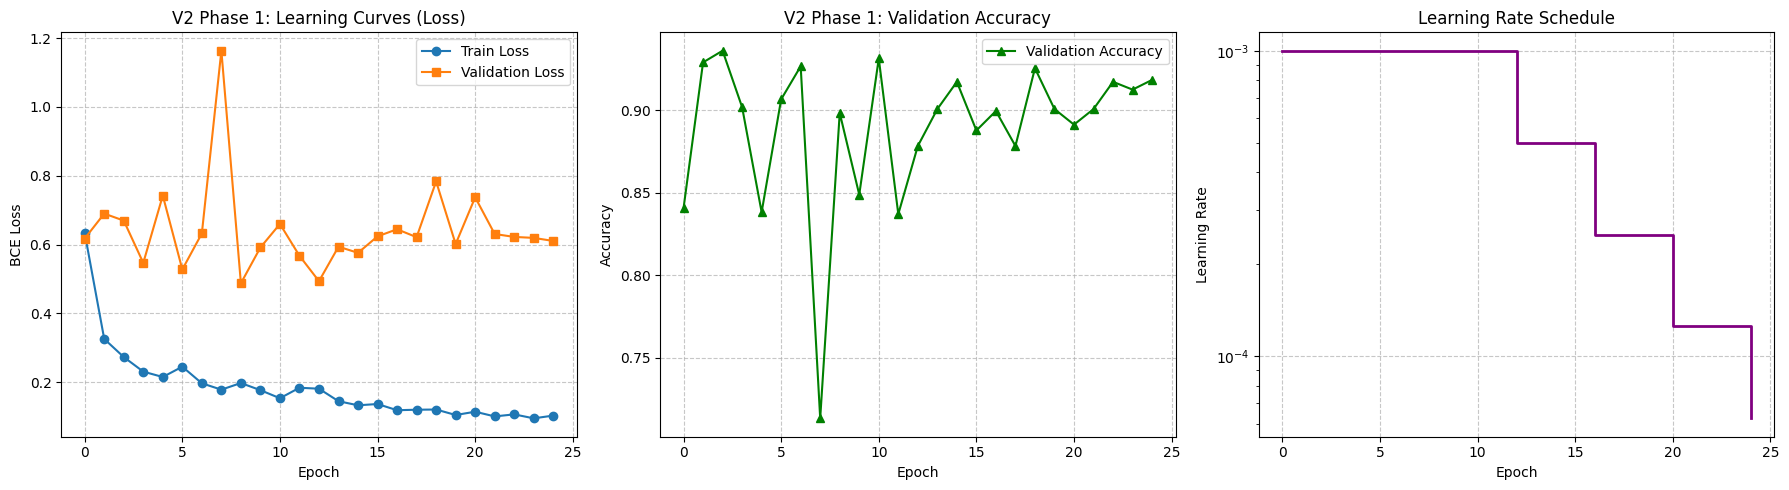

In [9]:
# Train the V2 model for 25 epochs (giving the scheduler time to act)
NUM_EPOCHS_V2 = 25

t_loss, v_loss, v_acc, lr_hist = train_v2_model(
    model_v2, train_loader, val_loader, criterion_v2, optimizer_v2, scheduler_v2, num_epochs=NUM_EPOCHS_V2
)

# --- Plotting the V2 Learning Curves ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Losses
axes[0].plot(t_loss, label='Train Loss', marker='o')
axes[0].plot(v_loss, label='Validation Loss', marker='s')
axes[0].set_title('V2 Phase 1: Learning Curves (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Validation Accuracy
axes[1].plot(v_acc, label='Validation Accuracy', color='green', marker='^')
axes[1].set_title('V2 Phase 1: Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Learning Rate Decay
axes[2].step(range(NUM_EPOCHS_V2), lr_hist, where='post', color='purple', linewidth=2)
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log') # Log scale is best for viewing LR drops
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Evaluating V2 Phase 1 (Cough Detection) on Test Set ---

V2 Classification Report:


               precision    recall  f1-score   support

Non-Cough (0)       0.97      0.94      0.96       692
    Cough (1)       0.77      0.86      0.82       155

     accuracy                           0.93       847
    macro avg       0.87      0.90      0.89       847
 weighted avg       0.93      0.93      0.93       847



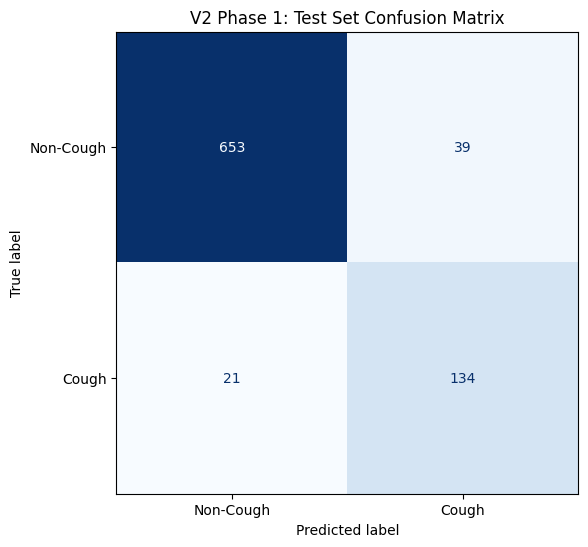

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_v2_phase1_on_test(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("--- Evaluating V2 Phase 1 (Cough Detection) on Test Set ---")
    
    with torch.no_grad():
        for batch in test_loader:
            audio = batch['audio']
            motion = batch['motion']
            labels = batch['label']
            
            logits = model(audio, motion)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int()
            
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # 1. Classification Report
    print("\nV2 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Non-Cough (0)', 'Cough (1)']))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Cough', 'Cough'])
    
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title('V2 Phase 1: Test Set Confusion Matrix')
    plt.show()

# Run the evaluation
evaluate_v2_phase1_on_test(model_v2, test_loader)

In [11]:
import os
import torch

# Ensure models directory exists
models_dir = os.path.join(DATA_ROOT, '..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Save the highly sensitive V2 weights
model_v2_save_path = os.path.join(models_dir, 'dl_baseline_v2_cough_det.pth')
torch.save(model_v2.state_dict(), model_v2_save_path)

print(f"--- V2 Phase 1 Model Successfully Saved ---")
print(f"Location: {model_v2_save_path}")

--- V2 Phase 1 Model Successfully Saved ---
Location: ../data\..\models\dl_baseline_v2_cough_det.pth


Running Centered Inference on Record: 3


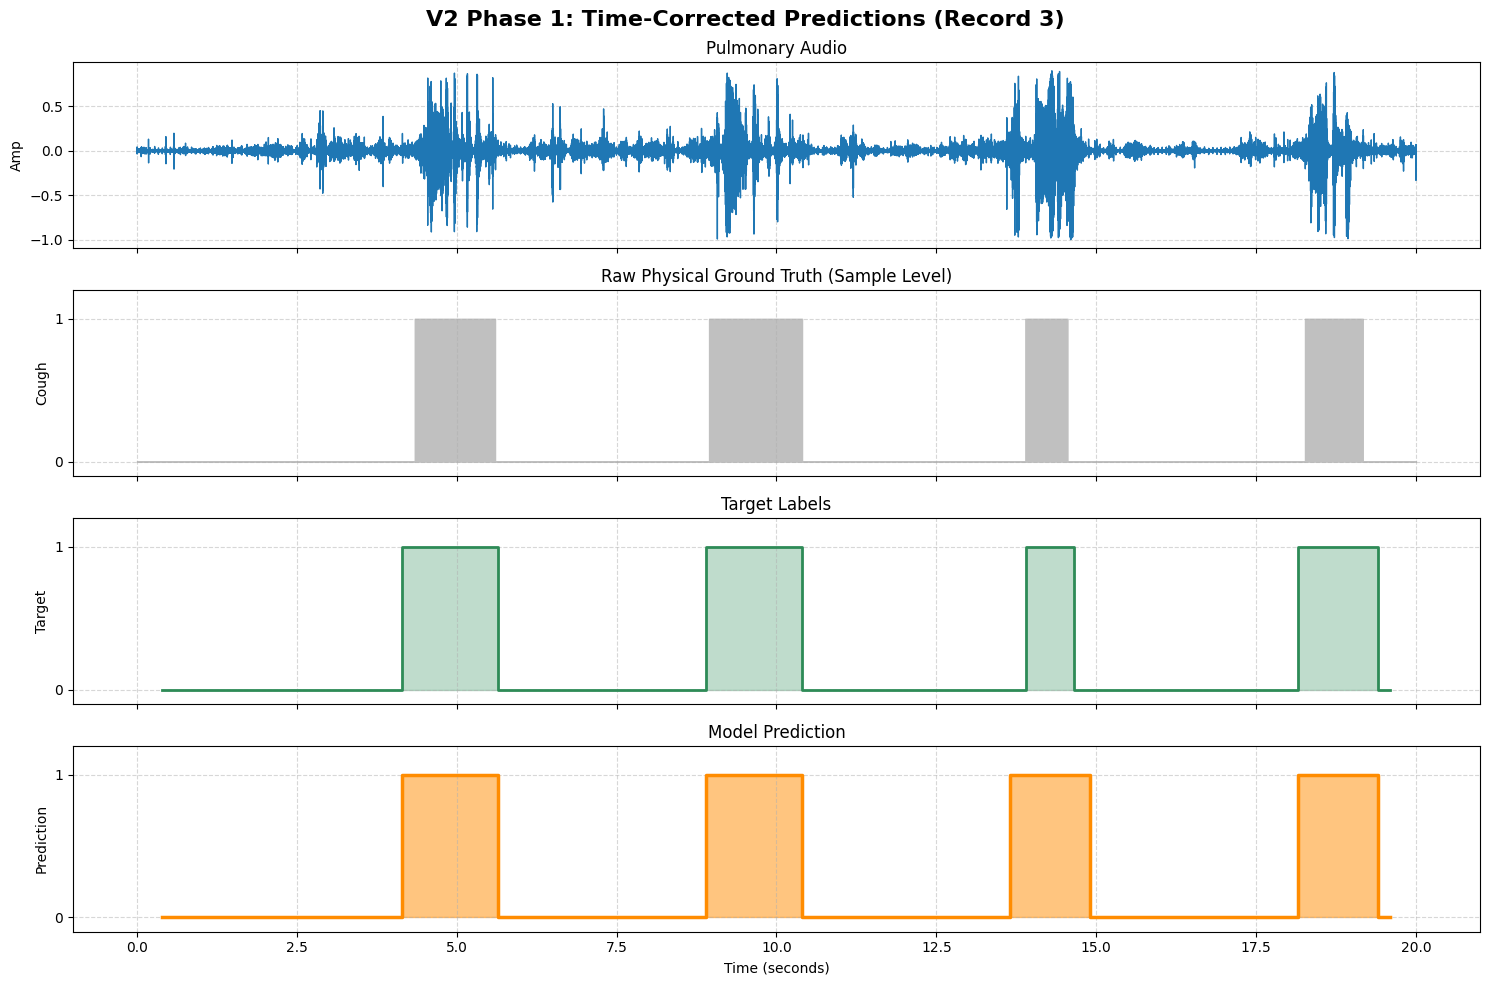

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_v2_predictions_centered(record_id, metadata_df, model):
    print(f"Running Centered Inference on Record: {record_id}")
    
    # 1. Load data and generate windows
    prep = load_record_preprocessed(record_id, metadata_df, DATA_ROOT)
    win_results = build_centered_windows_for_record(
        prep, window_length_sec=1.0, hop_length_sec=0.25
    )
    
    audio_tensors = torch.tensor(win_results['audio_windows'], dtype=torch.float32)
    motion_tensors = torch.tensor(win_results['motion_windows'], dtype=torch.float32)
    original_spans = win_results['spans']
    gt_window_labels = win_results['labels']
    
    # 2. Run Model Inference
    model.eval()
    with torch.no_grad():
        logits = model(audio_tensors, motion_tensors)
        probs = torch.sigmoid(logits)
        predicted_labels = (probs >= 0.5).int().numpy()
        
    # --- 3. THE CORRECTION: Map labels to the center of the window ---
    # Since window is 1.0s and hop is 0.25s, the "center chunk" is from 0.40s to 0.60s
    effective_spans = []
    for (start_sec, end_sec) in original_spans:
        center_start = start_sec + 0.40
        center_end = start_sec + 0.60
        effective_spans.append((center_start, center_end))
        
    duration = prep['duration_sec']
    t_audio = np.linspace(0, duration, len(prep['pulm_bp']), endpoint=False)
    
    # Step function data using the corrected effective spans
    t_window_steps = [s[0] for s in effective_spans] + [effective_spans[-1][1]]
    step_gt = list(gt_window_labels) + [gt_window_labels[-1]]
    step_pred = list(predicted_labels) + [predicted_labels[-1]]
    
    # 4. Create the Plot
    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
    fig.suptitle(f"V2 Phase 1: Time-Corrected Predictions (Record {record_id})", fontsize=16, fontweight='bold')
    
    def plot_norm(sig):
        c = sig - np.median(sig)
        m = np.max(np.abs(c))
        return c/m if m > 0 else c

    # A: Pulmonary Audio
    axes[0].plot(t_audio, plot_norm(prep['pulm_bp']), color='#1f77b4', linewidth=1)
    axes[0].set_title('Pulmonary Audio')
    axes[0].set_ylabel('Amp')
    
    # B: Raw Physical Ground Truth
    axes[1].fill_between(t_audio, 0, prep['cough_label'], color='silver', step='pre')
    axes[1].set_title('Raw Physical Ground Truth (Sample Level)')
    axes[1].set_ylabel('Cough')
    
    # C: Target Labels
    axes[2].step(t_window_steps, step_gt, where='post', color='seagreen', linewidth=2)
    axes[2].fill_between(t_window_steps, 0, step_gt, step='post', color='seagreen', alpha=0.3)
    axes[2].set_title('Target Labels')
    axes[2].set_ylabel('Target')
    
    # D: Model Predictions
    axes[3].step(t_window_steps, step_pred, where='post', color='darkorange', linewidth=2.5)
    axes[3].fill_between(t_window_steps, 0, step_pred, step='post', color='darkorange', alpha=0.5)
    axes[3].set_title('Model Prediction')
    axes[3].set_ylabel('Prediction')
    axes[3].set_xlabel('Time (seconds)')
    
    for ax in axes[1:]:
        ax.set_yticks([0, 1])
        ax.set_ylim(-0.1, 1.2)
        
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Run the updated visualization
test_rec_id = 3
visualize_v2_predictions_centered(test_rec_id, df_meta, model_v2)


--- Phase 2 Activity Classification ---
Classes (excluding running): ['sitting', 'standing', 'walking']
Record counts -> Train: 48 | Val: 11 | Test: 11


Train set: (3696, 2, 4800) | Labels: (3696,)
Val set:   (847, 2, 4800) | Labels: (847,)
Test set:  (847, 2, 4800) | Labels: (847,)
Train class counts: [2156  539 1001]


Phase2 Epoch 01/20 | LR 0.001000 | TrainLoss 0.9896 Acc 53.03% | ValLoss 1.0422 Acc 41.56%


Phase2 Epoch 02/20 | LR 0.001000 | TrainLoss 0.6962 Acc 66.13% | ValLoss 1.1226 Acc 44.51%


Phase2 Epoch 03/20 | LR 0.001000 | TrainLoss 0.5012 Acc 78.22% | ValLoss 0.8181 Acc 71.19%


...

Phase2 Epoch 16/20 | LR 0.001000 | TrainLoss 0.1906 Acc 92.59% | ValLoss 0.4695 Acc 85.95%


Phase2 Epoch 17/20 | LR 0.000500 | TrainLoss 0.1975 Acc 92.15% | ValLoss 0.5421 Acc 87.96%


Phase2 Epoch 18/20 | LR 0.000500 | TrainLoss 0.1572 Acc 93.59% | ValLoss 0.3894 Acc 90.44%


Phase2 Epoch 19/20 | LR 0.000500 | TrainLoss 0.1473 Acc 94.16% | ValLoss 0.4513 Acc 88.31%


Phase2 Epoch 20/20 | LR 0.000500 | TrainLoss 0.1448 Acc 93.56% | ValLoss 0.3991 Acc 91.38%

--- Phase 2 Test Results ---
              precision    recall  f1-score   support

     sitting       0.70      0.94      0.80       385
    standing       0.00      0.00      0.00       154
     walking       0.88      0.92      0.90       308

    accuracy                           0.76       847
   macro avg       0.53      0.62      0.57       847
weighted avg       0.64      0.76      0.69       847



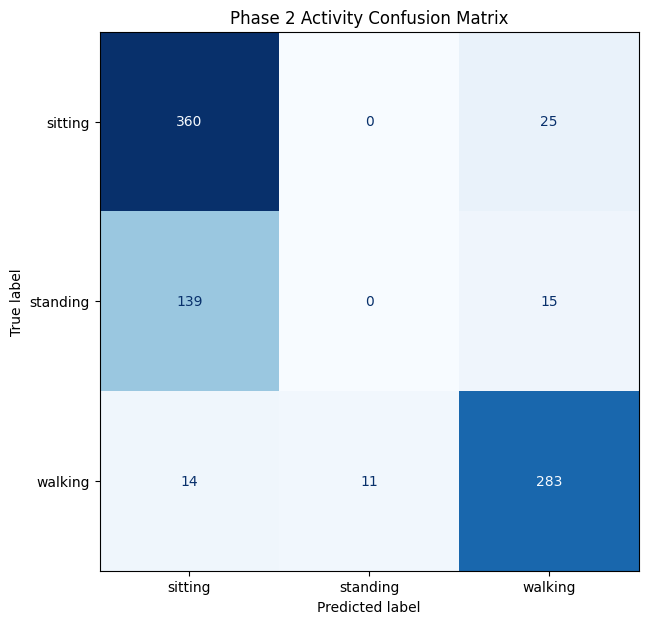

In [13]:
# Phase 2: Activity Classification (multi-class)
# Exclude `running` because the dataset has only a couple of files for it.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Record -> activity mapping from metadata
activity_by_record = df_meta.set_index("record_id")["activity"].to_dict()

def _ensure_record_splits():
    # train_recs/val_recs/test_recs are created in the V2 split cell, but keep this robust.
    global train_recs, val_recs, test_recs
    if ("train_recs" not in globals()) or ("val_recs" not in globals()) or ("test_recs" not in globals()):
        train_recs, val_recs, test_recs = split_records(df_meta)


def filter_records_excluding_activity(record_ids, exclude_activity={"running"}):
    return [rid for rid in record_ids if activity_by_record.get(rid) not in exclude_activity]

_ensure_record_splits()

train_recs_p2 = filter_records_excluding_activity(list(train_recs), exclude_activity={"running"})
val_recs_p2 = filter_records_excluding_activity(list(val_recs), exclude_activity={"running"})
test_recs_p2 = filter_records_excluding_activity(list(test_recs), exclude_activity={"running"})

activity_classes = sorted(
    set(activity_by_record[rid] for rid in (train_recs_p2 + val_recs_p2 + test_recs_p2))
)
activity_to_idx = {a: i for i, a in enumerate(activity_classes)}
num_classes_v2 = len(activity_classes)

print("\n--- Phase 2 Activity Classification ---")
print(f"Classes (excluding running): {activity_classes}")
print(f"Record counts -> Train: {len(train_recs_p2)} | Val: {len(val_recs_p2)} | Test: {len(test_recs_p2)}")


def build_v2_activity_dataset(record_ids, metadata_df, window_length_sec=1.0, hop_length_sec=0.25):
    """Builds window-level samples where each window inherits the record's activity label."""
    all_audio, all_motion, all_labels = [], [], []

    for rec_id in record_ids:
        act = activity_by_record.get(rec_id)
        if act is None or act not in activity_to_idx:
            continue

        prep_record = load_record_preprocessed(rec_id, metadata_df, DATA_ROOT)
        win_results = build_centered_windows_for_record(
            prep_record, window_length_sec=window_length_sec, hop_length_sec=hop_length_sec
        )
        n_w = len(win_results["labels"])
        if n_w == 0:
            continue

        y_act = np.full((n_w,), activity_to_idx[act], dtype=np.int64)
        all_audio.append(win_results["audio_windows"])
        all_motion.append(win_results["motion_windows"])
        all_labels.append(y_act)

    if len(all_audio) == 0:
        raise RuntimeError("Phase 2 dataset is empty after excluding activities.")

    return (
        np.vstack(all_audio),
        np.vstack(all_motion),
        np.concatenate(all_labels),
    )


X_a_train_p2, X_m_train_p2, y_train_p2 = build_v2_activity_dataset(train_recs_p2, df_meta)
X_a_val_p2, X_m_val_p2, y_val_p2 = build_v2_activity_dataset(val_recs_p2, df_meta)
X_a_test_p2, X_m_test_p2, y_test_p2 = build_v2_activity_dataset(test_recs_p2, df_meta)

print(f"Train set: {X_a_train_p2.shape} | Labels: {y_train_p2.shape}")
print(f"Val set:   {X_a_val_p2.shape} | Labels: {y_val_p2.shape}")
print(f"Test set:  {X_a_test_p2.shape} | Labels: {y_test_p2.shape}")
print("Train class counts:", np.bincount(y_train_p2, minlength=num_classes_v2))


class ActivityMultimodalDataset(Dataset):
    def __init__(self, X_audio, X_motion, labels):
        self.audio = torch.tensor(X_audio, dtype=torch.float32)
        self.motion = torch.tensor(X_motion, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)  # CE expects long

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"audio": self.audio[idx], "motion": self.motion[idx], "label": self.labels[idx]}


BATCH_SIZE_P2 = 32
train_loader_p2 = DataLoader(ActivityMultimodalDataset(X_a_train_p2, X_m_train_p2, y_train_p2),
                              batch_size=BATCH_SIZE_P2, shuffle=True)
val_loader_p2 = DataLoader(ActivityMultimodalDataset(X_a_val_p2, X_m_val_p2, y_val_p2),
                            batch_size=BATCH_SIZE_P2, shuffle=False)
test_loader_p2 = DataLoader(ActivityMultimodalDataset(X_a_test_p2, X_m_test_p2, y_test_p2),
                             batch_size=BATCH_SIZE_P2, shuffle=False)


class DualBranchActivityCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.audio_branch = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=15, stride=2, padding=7), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.motion_branch = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=5, stride=1, padding=2), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, audio, motion):
        x_a = self.audio_branch(audio).squeeze(-1)
        x_m = self.motion_branch(motion).squeeze(-1)
        return self.classifier(torch.cat((x_a, x_m), dim=1))


model_p2_v2 = DualBranchActivityCNN(num_classes=num_classes_v2).to(device)

# Class-weighted cross-entropy for imbalance
class_counts = np.bincount(y_train_p2, minlength=num_classes_v2).astype(np.float32)
class_weights = class_counts.sum() / (class_counts + 1e-6)
criterion_p2 = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
)

optimizer_p2 = optim.AdamW(model_p2_v2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_p2, mode="min", factor=0.5, patience=3)


def train_activity_model(model, train_loader, val_loader, num_epochs=20):
    for epoch in range(num_epochs):
        # Train
        model.train()
        running_train_loss = 0.0
        n_train = 0
        correct_train = 0

        for batch in train_loader:
            audio = batch["audio"].to(device)
            motion = batch["motion"].to(device)
            labels = batch["label"].to(device)  # [B]

            # Augmentation is label-invariant at record-level for activity.
            audio_aug, motion_aug = augment_multimodal_batch(
                audio, motion,
                shift_max_sec=0.15,
                noise_level_audio=0.02,
                noise_level_motion=0.01
            )

            optimizer_p2.zero_grad()
            logits = model(audio_aug, motion_aug)  # [B, C]
            loss = criterion_p2(logits, labels)
            loss.backward()
            optimizer_p2.step()

            bs = audio.size(0)
            running_train_loss += loss.item() * bs
            n_train += bs
            correct_train += (logits.argmax(dim=1) == labels).sum().item()

        epoch_train_loss = running_train_loss / max(n_train, 1)
        epoch_train_acc = correct_train / max(n_train, 1)

        # Validate
        model.eval()
        running_val_loss = 0.0
        n_val = 0
        correct_val = 0

        with torch.no_grad():
            for batch in val_loader:
                audio = batch["audio"].to(device)
                motion = batch["motion"].to(device)
                labels = batch["label"].to(device)

                logits = model(audio, motion)
                loss = criterion_p2(logits, labels)

                bs = audio.size(0)
                running_val_loss += loss.item() * bs
                n_val += bs
                correct_val += (logits.argmax(dim=1) == labels).sum().item()

        epoch_val_loss = running_val_loss / max(n_val, 1)
        epoch_val_acc = correct_val / max(n_val, 1)

        scheduler_p2.step(epoch_val_loss)

        print(
            f"Phase2 Epoch {epoch+1:02d}/{num_epochs} | LR {optimizer_p2.param_groups[0]['lr']:.6f} | "
            f"TrainLoss {epoch_train_loss:.4f} Acc {epoch_train_acc*100:.2f}% | "
            f"ValLoss {epoch_val_loss:.4f} Acc {epoch_val_acc*100:.2f}%"
        )


train_activity_model(model_p2_v2, train_loader_p2, val_loader_p2, num_epochs=20)


# Test evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model_p2_v2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader_p2:
        audio = batch["audio"].to(device)
        motion = batch["motion"].to(device)
        labels = batch["label"].to(device)

        logits = model_p2_v2(audio, motion)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

print("\n--- Phase 2 Test Results ---")
labels_eval = list(range(num_classes_v2))
print(
    classification_report(
        all_labels,
        all_preds,
        labels=labels_eval,
        target_names=activity_classes,
        zero_division=0,
    )
)

cm = confusion_matrix(all_labels, all_preds, labels=labels_eval)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Phase 2 Activity Confusion Matrix")
plt.show()


In [ ]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt


def _resolve_record_id_from_input(file_or_record, metadata_df):
    """Accept record_id (int/str) or file path/name and return matched record_id."""
    # 1) Direct record_id usage
    if isinstance(file_or_record, (int, np.integer)):
        return int(file_or_record)

    text = str(file_or_record).strip()
    if text.isdigit():
        return int(text)

    # 2) Match by file path/name against string columns in metadata
    p = Path(text)
    candidate_full = str(p).replace('\\', '/').lower()
    candidate_name = p.name.lower()

    str_cols = [c for c in metadata_df.columns if metadata_df[c].dtype == object]
    for _, row in metadata_df.iterrows():
        for col in str_cols:
            val = row[col]
            if not isinstance(val, str) or len(val) == 0:
                continue
            val_norm = val.replace('\\', '/').lower()
            val_name = Path(val_norm).name
            if (
                candidate_full == val_norm
                or candidate_name == val_name
                or candidate_name in val_norm
            ):
                return int(row['record_id'])

    raise ValueError(
        f"Could not resolve record from input '{file_or_record}'. "
        "Pass a valid record_id or a file path/name existing in df_meta."
    )


def visualize_phase2_activity_prediction(file_or_record, metadata_df=df_meta, model=model_p2_v2):
    """
    Plot Phase-2 activity predictions for one file/record.

    Inputs
    - file_or_record: record_id OR file path/name that exists in metadata
    - metadata_df: metadata dataframe (defaults to df_meta)
    - model: trained phase-2 model (defaults to model_p2_v2)
    """
    record_id = _resolve_record_id_from_input(file_or_record, metadata_df)
    gt_activity = activity_by_record.get(record_id, 'unknown')

    prep = load_record_preprocessed(record_id, metadata_df, DATA_ROOT)
    win_results = build_centered_windows_for_record(
        prep,
        window_length_sec=1.0,
        hop_length_sec=0.25,
    )

    audio_windows = win_results['audio_windows']
    motion_windows = win_results['motion_windows']
    spans = win_results['spans']

    if len(spans) == 0:
        raise ValueError(f"No windows produced for record_id={record_id}.")

    model.eval()
    with torch.no_grad():
        audio_t = torch.tensor(audio_windows, dtype=torch.float32, device=device)
        motion_t = torch.tensor(motion_windows, dtype=torch.float32, device=device)
        logits = model(audio_t, motion_t)
        pred_idx = logits.argmax(dim=1).cpu().numpy()

    idx_to_activity = {v: k for k, v in activity_to_idx.items()}
    pred_activity_names = [idx_to_activity[int(i)] for i in pred_idx]

    # Build step timeline aligned to effective center region of each window.
    effective_spans = []
    for start_sec, _ in spans:
        center_start = start_sec + 0.40
        center_end = start_sec + 0.60
        effective_spans.append((center_start, center_end))

    t_steps = [s[0] for s in effective_spans] + [effective_spans[-1][1]]
    gt_idx = activity_to_idx.get(gt_activity, -1)
    gt_steps = [gt_idx] * len(t_steps)
    pred_steps = list(pred_idx) + [pred_idx[-1]]

    duration = prep['duration_sec']
    t_audio = np.linspace(0, duration, len(prep['pulm_bp']), endpoint=False)
    t_motion = np.linspace(0, duration, len(prep['stretch_norm']), endpoint=False)

    def _norm(sig):
        x = sig - np.median(sig)
        m = np.max(np.abs(x))
        return x / m if m > 0 else x

    fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(
        f"Phase 2 Activity Visualization - Record {record_id} | GT: {gt_activity}",
        fontsize=15,
        fontweight='bold',
    )

    axes[0].plot(t_audio, _norm(prep['pulm_bp']), color='#1f77b4', linewidth=1)
    axes[0].set_ylabel('Pulm')
    axes[0].set_title('Pulmonary Audio (normalized)')

    axes[1].plot(t_motion, _norm(prep['stretch_norm']), color='#2ca02c', linewidth=1)
    axes[1].set_ylabel('Stretch')
    axes[1].set_title('Stretch Signal (normalized)')

    axes[2].plot(t_motion, _norm(prep['accz_norm']), color='#9467bd', linewidth=1)
    axes[2].set_ylabel('AccZ')
    axes[2].set_title('Acceleration Z (normalized)')

    axes[3].step(t_steps, gt_steps, where='post', color='seagreen', linewidth=2)
    axes[3].fill_between(t_steps, 0, gt_steps, step='post', color='seagreen', alpha=0.20)
    axes[3].set_title('Ground Truth Activity')
    axes[3].set_ylabel('GT idx')

    axes[4].step(t_steps, pred_steps, where='post', color='darkorange', linewidth=2)
    axes[4].fill_between(t_steps, 0, pred_steps, step='post', color='darkorange', alpha=0.25)
    axes[4].set_title('Phase 2 Predicted Activity')
    axes[4].set_ylabel('Pred idx')
    axes[4].set_xlabel('Time (seconds)')

    class_ticks = list(range(len(activity_classes)))
    class_names = [idx_to_activity[i] for i in class_ticks]
    for ax in (axes[3], axes[4]):
        ax.set_yticks(class_ticks)
        ax.set_yticklabels(class_names)
        ax.set_ylim(-0.5, len(class_ticks) - 0.5)
        ax.grid(True, linestyle='--', alpha=0.4)

    for ax in axes[:3]:
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    unique_pred = sorted(set(pred_activity_names))
    print(f"Resolved input '{file_or_record}' -> record_id={record_id}")
    print(f"Ground truth activity: {gt_activity}")
    print(f"Predicted activities present in timeline: {unique_pred}")


# Example usage:
visualize_phase2_activity_prediction(3)
# visualize_phase2_activity_prediction('some_file_name.wav')

: 